# Chapter 5: Projective and birational geometry

Source orientation: printed pages 87-100, physical PDF pages 85-98. The source span introduces projective varieties by affine chart gluing, then develops homogeneous ideals, the homogeneous Nullstellensatz, rational functions and maps, birational equivalence, rational varieties, and products via Segre-style rank-one embeddings.

## Chapter Goal

The goal is to make the projective and birational dictionary executable. By the end, a reader should be able to move between a homogeneous equation, its affine charts, its cone, its rational functions, and the dense open sets where a rational formula becomes an honest isomorphism. The notebook emphasizes the checks that catch common mistakes: using a non-homogeneous equation in projective space, forgetting the irrelevant ideal, ignoring a denominator, or treating a birational map as if it were everywhere defined.

## Compact Visualization Storyboard

1. **Homogeneous cone and affine chart slices.** A projective variety is seen through the affine cone with the vertex removed, then through standard affine chart slices.
2. **Gluing of `P^1` and a projective cubic.** The coordinate change `x -> 1/x` for `P^1` and `(x,y) -> (x/y,1/y)` for the cubic become visible as matched points in two charts.
3. **Rational normal curve.** The twisted cubic is plotted in an affine chart while SymPy checks the rank-one Hankel minors.
4. **Quadric projection.** The quadric `X0*X3 = X1*X2` is shown as a ruled surface, with a Plotly lab for rotating the projection picture and inspecting the open set where the inverse works.
5. **Birational equivalence.** A proof-state diagram separates rational formulas, domains of definition, dense open sets, and function fields.
6. **Segre and Veronese rank-one tests.** Product and Veronese embeddings become matrix rank conditions with exact symbolic minors.


In [1]:
from pathlib import Path
import sys

def find_book_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "scripts" / "validate_uag_course.py").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate Undergraduate-Algebraic-Geometry course root")

BOOK_ROOT = find_book_root(Path.cwd())
COURSE_ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
ARTIFACT_ROOT = COURSE_ARTIFACT_ROOT / "chapter-05"
for child in ["figures", "html", "checks", "tables"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

for item in [BOOK_ROOT, BOOK_ROOT / "scripts"]:
    if str(item) not in sys.path:
        sys.path.insert(0, str(item))

print("BOOK_ROOT located")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


BOOK_ROOT located
ARTIFACT_ROOT = artifacts\chapter-05


## Computational Translation Guide

| Chapter object | Computational form used here | What must be checked |
| --- | --- | --- |
| Projective point `[X0:...:Xn]` | A nonzero vector modulo scalar multiplication | Statements do not depend on the representative |
| Homogeneous polynomial | A sum of monomials of one total degree | `F(lambda X) = lambda^d F(X)`, so `F=0` is well defined on projective points |
| Homogeneous coordinate ring | `k[X0,...,Xn] / I` with `I` homogeneous | The irrelevant ideal `(X0,...,Xn)` represents the deleted cone vertex, not a projective point |
| Standard affine chart | Set one coordinate equal to `1` and dehomogenize | Different charts agree on overlaps after the correct coordinate change |
| Rational function on `V` | Quotient `g/h` of homogeneous forms of the same degree | The denominator gives the open domain, and equivalent quotients differ by `I(V)` |
| Rational map | Projective coordinate formulas, considered up to common nonzero scaling | The undefined locus is where no representative gives a nonzero coordinate tuple |
| Birational equivalence | Inverse rational maps, or an isomorphism on dense open sets | Exceptional or contracted loci are removed before calling the map an isomorphism |
| Product of projective varieties | Segre coordinates `Uij = Xi*Yj` | The image is a rank-one matrix locus, cut out by `2 x 2` minors |


In [2]:
import json
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display
from matplotlib.patches import ConnectionPatch, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from utils.artifacts import assert_artifacts, display_artifact, image_stats
from utils.validation import validate_chapter_outputs, write_final_sanity

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
paths = {"figures": [], "html": [], "checks": [], "tables": []}
metrics = {}
storyboard_rows = []


def book_rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def add_artifact(kind: str, path: Path) -> Path:
    resolved = Path(path)
    if resolved not in paths[kind]:
        paths[kind].append(resolved)
    return resolved


def save_fig(fig, filename: str) -> Path:
    path = FIGURES / filename
    fig.savefig(path, dpi=165, bbox_inches="tight")
    plt.close(fig)
    return add_artifact("figures", path)


def save_html(fig, filename: str) -> Path:
    path = HTML / filename
    fig.write_html(str(path), include_plotlyjs=True, full_html=True)
    return add_artifact("html", path)


def save_check(data: dict, filename: str) -> Path:
    path = CHECKS / filename
    path.write_text(json.dumps(data, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    return add_artifact("checks", path)


def save_table(frame: pd.DataFrame, filename: str) -> Path:
    path = TABLES / filename
    frame.to_csv(path, index=False)
    return add_artifact("tables", path)


def record_visual(concept: str, representation: str, library: str, artifact: Path, inspection: str, validation: str) -> None:
    storyboard_rows.append({
        "concept": concept,
        "representation": representation,
        "library": library,
        "artifact": book_rel(artifact),
        "inspection_target": inspection,
        "validation_or_invariant": validation,
    })


## Homogeneous Equations, Cones, and Affine Charts

A homogeneous equation does not define a function on projective space, but its zero condition is well defined because scaling the representative only scales the value. The affine cone remembers all scalar representatives; projective space removes the origin and identifies points along each nonzero line. A standard affine chart is a slice through that cone, such as `X0 = 1`.

The conic `X0*X2 - X1^2 = 0` is a compact model for the chapter. It is simple enough to draw as rays in the affine cone, but it already shows why the irrelevant ideal matters: the cone vertex satisfies every positive-degree homogeneous equation but is not a projective point.


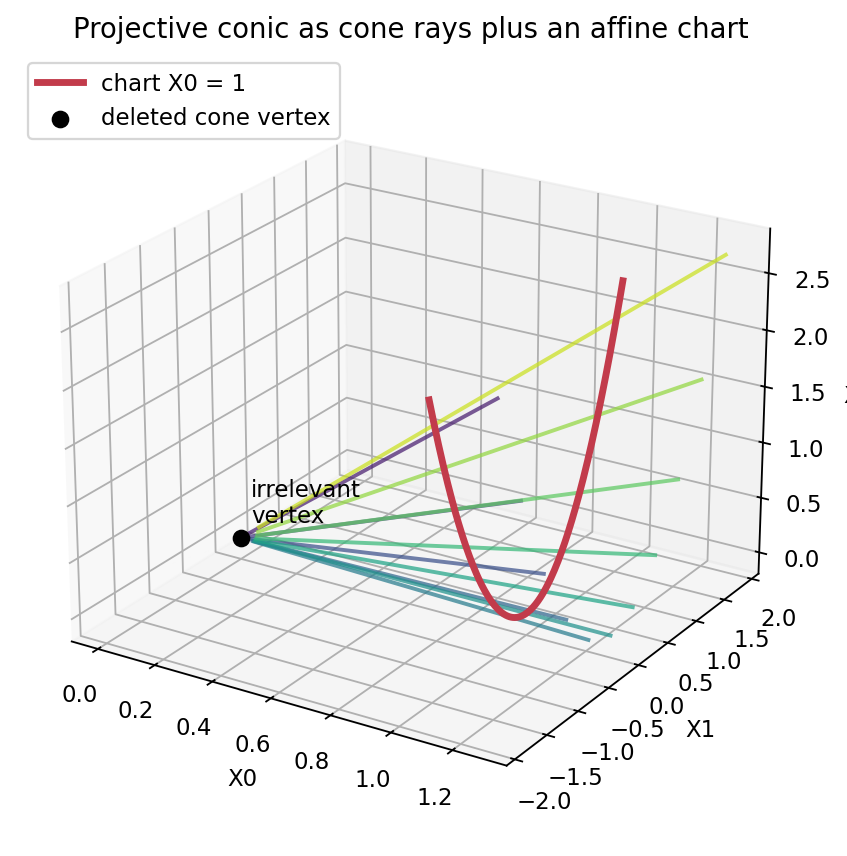

In [3]:
def draw_homogeneous_cone() -> Path:
    fig = plt.figure(figsize=(8.6, 6.2))
    ax = fig.add_subplot(111, projection="3d")
    t_values = np.linspace(-1.45, 1.45, 11)
    scales = np.linspace(0.05, 1.28, 28)
    palette = plt.cm.viridis(np.linspace(0.08, 0.92, len(t_values)))
    cone_points = []
    for color, t in zip(palette, t_values):
        ray = np.column_stack([scales, scales * t, scales * t * t])
        cone_points.append(ray)
        ax.plot(ray[:, 0], ray[:, 1], ray[:, 2], color=color, alpha=0.72, lw=1.7)

    dense_t = np.linspace(-1.55, 1.55, 220)
    chart = np.column_stack([np.ones_like(dense_t), dense_t, dense_t**2])
    ax.plot(chart[:, 0], chart[:, 1], chart[:, 2], color="#c23b4b", lw=3.0, label="chart X0 = 1")
    ax.scatter([0], [0], [0], color="black", s=45, label="deleted cone vertex")
    ax.text(0.02, 0.08, 0.12, "irrelevant\nvertex", color="black")
    ax.set_title("Projective conic as cone rays plus an affine chart")
    ax.set_xlabel("X0")
    ax.set_ylabel("X1")
    ax.set_zlabel("X2")
    ax.view_init(elev=23, azim=-58)
    ax.legend(loc="upper left")

    all_points = np.vstack(cone_points + [chart])
    residual = all_points[:, 0] * all_points[:, 2] - all_points[:, 1] ** 2
    metrics["homogeneous_cone_max_residual"] = float(np.max(np.abs(residual)))
    return save_fig(fig, "homogeneous-cone-affine-charts.png")


cone_path = draw_homogeneous_cone()
record_visual(
    "homogeneous projective variety",
    "affine cone with chart slice and deleted vertex",
    "Matplotlib 3D because the cone, rays, and chart slice need a durable static view",
    cone_path,
    "Rays through the origin represent projective points; the red curve is the X0=1 affine chart.",
    "The sampled residual X0*X2 - X1^2 is zero up to floating tolerance.",
)
display_artifact(cone_path, width=760)


## Gluing `P^1` and Gluing a Cubic

`P^1` is covered by two copies of `A^1`. On the overlap, the coordinate change is `y = 1/x`. The point `x = 0` is not in the overlap; it is exactly where the other chart supplies the missing projective point.

The same habit scales to curves. For the projective cubic

`Y^2 Z = X^3 + a X Z^2 + b Z^3`,

the `Z = 1` chart has coordinates `(x,y)` with `y^2 = x^3 + a*x + b`. The `Y = 1` chart has coordinates `(u,z)` with `z = u^3 + a*u*z^2 + b*z^3`. On their overlap `Y != 0` and `Z != 0`, the change of coordinates is `(u,z) = (x/y, 1/y)`.


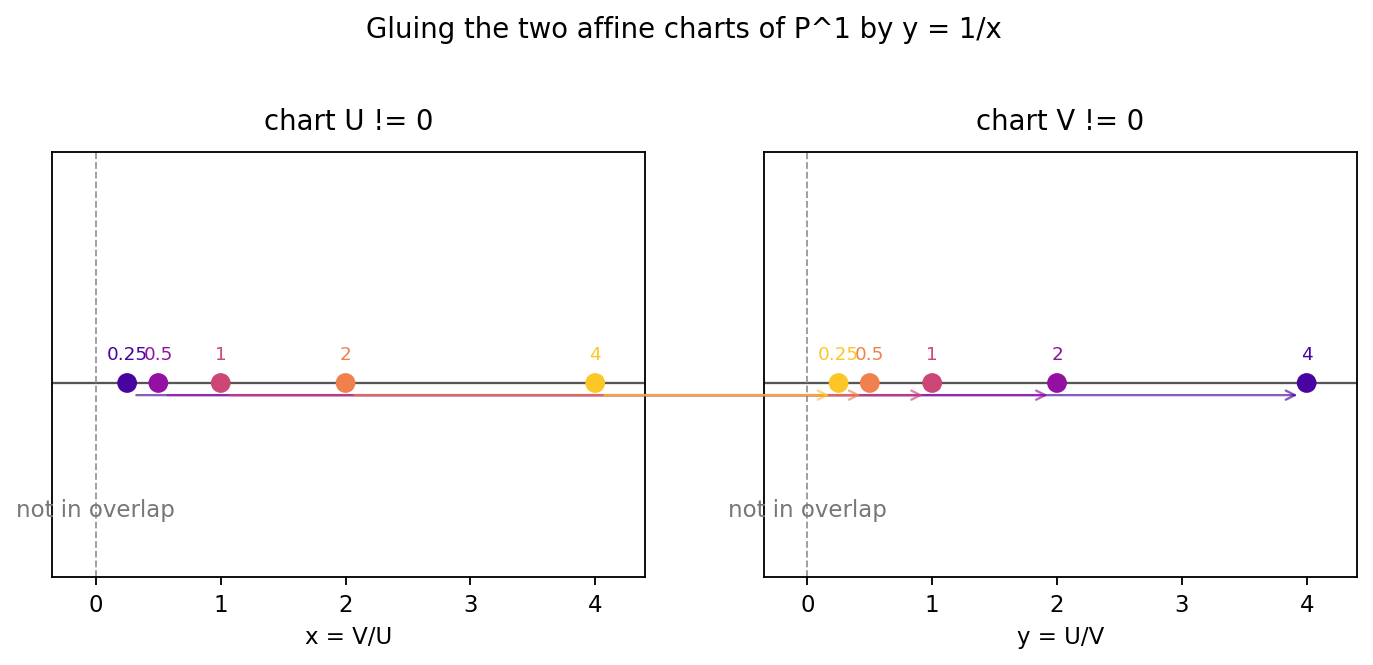

In [4]:
def draw_p1_gluing() -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6), sharey=True)
    x_values = np.array([0.25, 0.5, 1.0, 2.0, 4.0])
    y_values = 1 / x_values
    colors = plt.cm.plasma(np.linspace(0.12, 0.88, len(x_values)))

    for ax, title, label in zip(axes, ["chart U != 0", "chart V != 0"], ["x = V/U", "y = U/V"]):
        ax.axhline(0, color="#555555", lw=1.0)
        ax.axvline(0, color="#999999", lw=0.8, ls="--")
        ax.set_xlim(-0.35, 4.4)
        ax.set_ylim(-0.32, 0.38)
        ax.set_yticks([])
        ax.set_xlabel(label)
        ax.set_title(title, pad=10)
        ax.text(0, -0.22, "not in overlap", ha="center", color="#777777")

    axes[0].scatter(x_values, np.zeros_like(x_values), c=colors, s=58, zorder=5)
    axes[1].scatter(y_values, np.zeros_like(y_values), c=colors, s=58, zorder=5)
    for xval, yval, color in zip(x_values, y_values, colors):
        axes[0].annotate(f"{xval:g}", (xval, 0.04), ha="center", fontsize=8, color=color)
        axes[1].annotate(f"{yval:g}", (yval, 0.04), ha="center", fontsize=8, color=color)
        connector = ConnectionPatch(
            xyA=(xval, -0.02), coordsA=axes[0].transData,
            xyB=(yval, -0.02), coordsB=axes[1].transData,
            arrowstyle="->", shrinkA=4, shrinkB=4, mutation_scale=10,
            color=color, lw=1.0, alpha=0.65,
        )
        fig.add_artist(connector)

    fig.subplots_adjust(top=0.78, bottom=0.22, wspace=0.20)
    fig.suptitle("Gluing the two affine charts of P^1 by y = 1/x", y=0.96)
    metrics["p1_gluing_max_product_error"] = float(np.max(np.abs(x_values * y_values - 1)))
    return save_fig(fig, "projective-line-gluing.png")


p1_path = draw_p1_gluing()
record_visual(
    "P^1 affine chart gluing",
    "paired coordinate axes with reciprocal overlap arrows",
    "Matplotlib because a labeled 2D construction diagram is enough and exports reliably",
    p1_path,
    "Each colored point in one chart lands at its reciprocal in the other chart; zero is excluded from the overlap.",
    "For sampled overlap points, x*y - 1 has zero maximum error.",
)
display_artifact(p1_path, width=760)


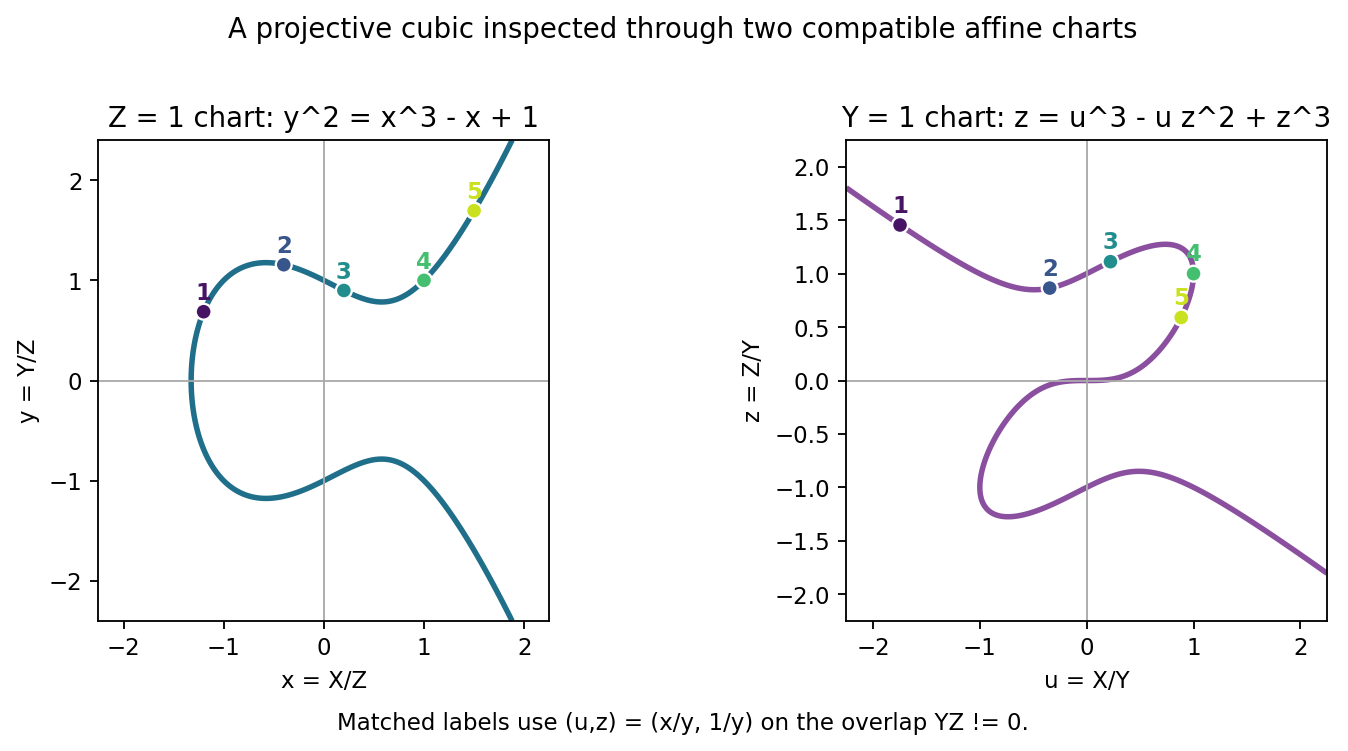

In [5]:
def draw_cubic_charts(a_val=-1.0, b_val=1.0) -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(10.7, 4.7))

    x_grid = np.linspace(-2.25, 2.25, 500)
    y_grid = np.linspace(-2.4, 2.4, 500)
    Xg, Yg = np.meshgrid(x_grid, y_grid)
    F0 = Yg**2 - (Xg**3 + a_val * Xg + b_val)
    axes[0].contour(Xg, Yg, F0, levels=[0], colors=["#1f6f8b"], linewidths=2.4)
    axes[0].axhline(0, color="#aaaaaa", lw=0.8)
    axes[0].axvline(0, color="#aaaaaa", lw=0.8)
    axes[0].set_title("Z = 1 chart: y^2 = x^3 - x + 1")
    axes[0].set_xlabel("x = X/Z")
    axes[0].set_ylabel("y = Y/Z")
    axes[0].set_aspect("equal", adjustable="box")

    u_grid = np.linspace(-2.25, 2.25, 520)
    z_grid = np.linspace(-2.25, 2.25, 520)
    Ug, Zg = np.meshgrid(u_grid, z_grid)
    F1 = Zg - Ug**3 - a_val * Ug * Zg**2 - b_val * Zg**3
    axes[1].contour(Ug, Zg, F1, levels=[0], colors=["#8b4f9f"], linewidths=2.4)
    axes[1].axhline(0, color="#aaaaaa", lw=0.8)
    axes[1].axvline(0, color="#aaaaaa", lw=0.8)
    axes[1].set_title("Y = 1 chart: z = u^3 - u z^2 + z^3")
    axes[1].set_xlabel("u = X/Y")
    axes[1].set_ylabel("z = Z/Y")
    axes[1].set_aspect("equal", adjustable="box")

    sample_x = np.array([-1.2, -0.4, 0.2, 1.0, 1.5])
    sample_y = np.sqrt(sample_x**3 + a_val * sample_x + b_val)
    sample_u = sample_x / sample_y
    sample_z = 1 / sample_y
    colors = plt.cm.viridis(np.linspace(0.05, 0.92, len(sample_x)))
    axes[0].scatter(sample_x, sample_y, c=colors, s=48, zorder=5, edgecolor="white")
    axes[1].scatter(sample_u, sample_z, c=colors, s=48, zorder=5, edgecolor="white")
    for idx, color in enumerate(colors, start=1):
        axes[0].annotate(str(idx), (sample_x[idx - 1], sample_y[idx - 1] + 0.12), ha="center", color=color, weight="bold")
        axes[1].annotate(str(idx), (sample_u[idx - 1], sample_z[idx - 1] + 0.12), ha="center", color=color, weight="bold")

    fig.subplots_adjust(top=0.80, bottom=0.18, wspace=0.26)
    fig.suptitle("A projective cubic inspected through two compatible affine charts", y=0.96)
    fig.text(0.5, 0.04, "Matched labels use (u,z) = (x/y, 1/y) on the overlap YZ != 0.", ha="center")

    residual = sample_z - sample_u**3 - a_val * sample_u * sample_z**2 - b_val * sample_z**3
    metrics["cubic_chart_sample_max_residual"] = float(np.max(np.abs(residual)))
    return save_fig(fig, "projective-cubic-affine-charts.png")


cubic_path = draw_cubic_charts()
record_visual(
    "projective cubic affine chart cover",
    "two implicit affine chart contours with matched overlap points",
    "Matplotlib contours because the chart equations are planar implicit curves",
    cubic_path,
    "Labels mark points transported from the Z=1 chart to the Y=1 chart by the projective coordinate change.",
    "Substituted overlap samples satisfy the Y=1 chart equation to numerical tolerance.",
)
display_artifact(cubic_path, width=820)


## Symbolic Scaffold: Homogeneous Scaling and Chart Agreement

The visual chart gluing should not be trusted only by inspection. The exact algebra below checks the two central invariants. First, the cubic equation is homogeneous of degree `3`, so its zero condition survives representative scaling. Second, the chart change sends a point of the `Z = 1` cubic into the `Y = 1` equation because the new equation becomes the old equation divided by `y^3`.


In [6]:
X, Y, Z, lam, a, b = sp.symbols("X Y Z lambda a b")
x, y = sp.symbols("x y")
F_cubic = Y**2 * Z - X**3 - a * X * Z**2 - b * Z**3
scaling_identity = sp.factor(F_cubic.subs({X: lam * X, Y: lam * Y, Z: lam * Z}) - lam**3 * F_cubic)

u_expr = x / y
z_expr = 1 / y
chart1_equation = z_expr - u_expr**3 - a * u_expr * z_expr**2 - b * z_expr**3
chart1_numerator = sp.factor(sp.together(chart1_equation).as_numer_denom()[0])
chart0_equation = y**2 - x**3 - a * x - b
chart_glue_identity = sp.factor(chart1_numerator - chart0_equation)

assert scaling_identity == 0
assert chart_glue_identity == 0
metrics.update({
    "homogeneous_scaling_identity": str(scaling_identity),
    "cubic_chart_glue_numerator": str(chart1_numerator),
    "cubic_chart_glue_identity": str(chart_glue_identity),
})

pd.DataFrame([
    {"check": "homogeneous scaling", "result": str(scaling_identity), "meaning": "F(lambda X)=lambda^3 F(X)"},
    {"check": "cubic chart gluing", "result": str(chart_glue_identity), "meaning": "Y=1 equation pulls back to the Z=1 equation"},
])


,check,result,meaning
0,homogeneous scaling,0,F(lambda X)=lambda^3 F(X)
1,cubic chart gluing,0,Y=1 equation pulls back to the Z=1 equation


## Rational Normal Curve: Equations from Rank-One Minors

The rational normal curve of degree `m` sends `[U:V]` to all degree `m` monomials in `U,V`. For `m = 3`, this is the twisted cubic in `P^3`:

`[U:V] -> [U^3 : U^2 V : U V^2 : V^3]`.

Its defining equations can be organized as the `2 x 2` minors of the Hankel matrix

`[[X0, X1, X2], [X1, X2, X3]]`.

The plot uses the affine chart `X0 = 1`, where the curve is `(t, t^2, t^3)`. The exact check substitutes the parametrization into all minors.


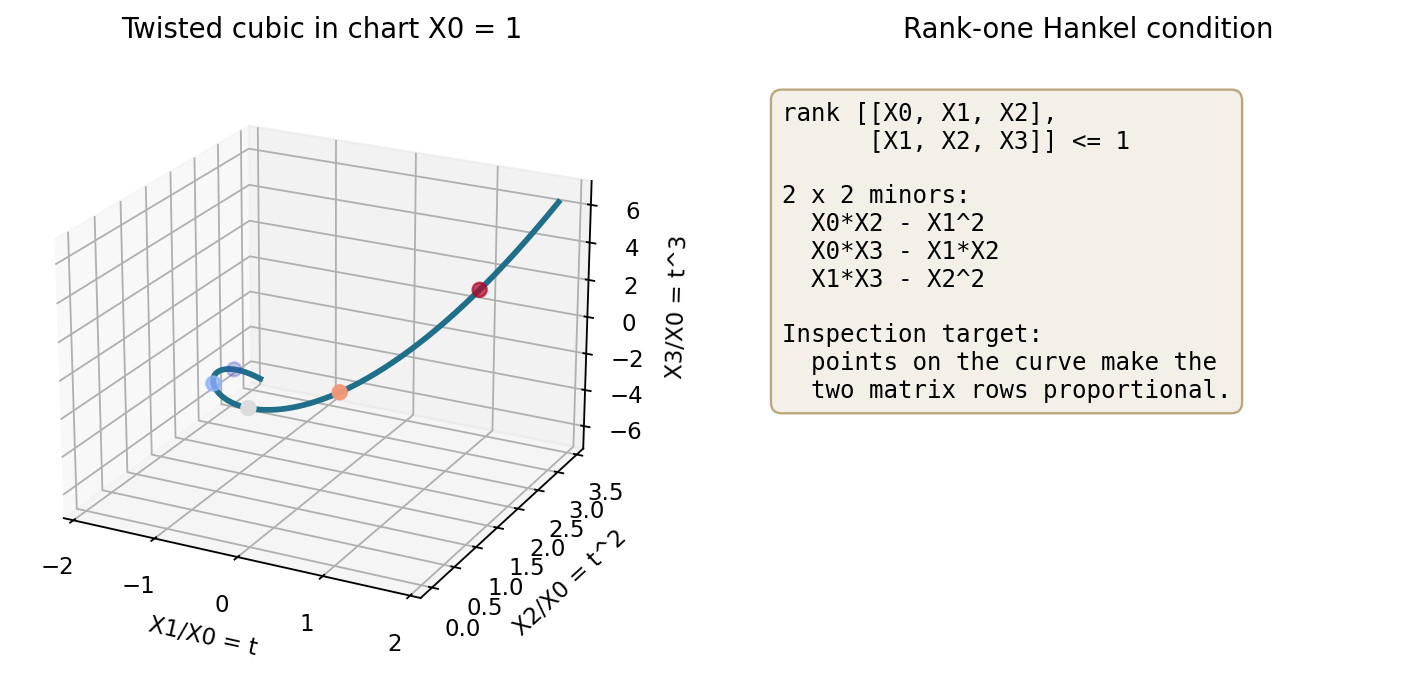

In [7]:
def draw_rational_normal_curve() -> Path:
    fig = plt.figure(figsize=(11.0, 4.8))
    ax = fig.add_subplot(1, 2, 1, projection="3d")
    t_values = np.linspace(-1.85, 1.85, 320)
    ax.plot(t_values, t_values**2, t_values**3, color="#1f6f8b", lw=2.5)
    sample_t = np.array([-1.5, -0.75, 0.0, 0.75, 1.5])
    ax.scatter(sample_t, sample_t**2, sample_t**3, c=sample_t, cmap="coolwarm", s=38, depthshade=True)
    ax.set_title("Twisted cubic in chart X0 = 1")
    ax.set_xlabel("X1/X0 = t")
    ax.set_ylabel("X2/X0 = t^2")
    ax.set_zlabel("X3/X0 = t^3")
    ax.view_init(elev=22, azim=-63)

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.axis("off")
    ax2.set_title("Rank-one Hankel condition")
    text = (
        "rank [[X0, X1, X2],\n"
        "      [X1, X2, X3]] <= 1\n\n"
        "2 x 2 minors:\n"
        "  X0*X2 - X1^2\n"
        "  X0*X3 - X1*X2\n"
        "  X1*X3 - X2^2\n\n"
        "Inspection target:\n"
        "  points on the curve make the\n"
        "  two matrix rows proportional."
    )
    ax2.text(0.02, 0.92, text, va="top", family="monospace", fontsize=10.5,
             bbox={"boxstyle": "round,pad=0.45", "fc": "#f4f0e8", "ec": "#b9a67a"})
    return save_fig(fig, "rational-normal-curve-rank-minors.png")


U, V = sp.symbols("U V")
X0, X1, X2, X3 = sp.symbols("X0 X1 X2 X3")
hankel = sp.Matrix([[X0, X1, X2], [X1, X2, X3]])
rnc_minors = [sp.factor(hankel.extract([0, 1], cols).det()) for cols in combinations(range(3), 2)]
rnc_subs = {X0: U**3, X1: U**2 * V, X2: U * V**2, X3: V**3}
rnc_minor_values = [sp.factor(minor.subs(rnc_subs)) for minor in rnc_minors]
assert all(value == 0 for value in rnc_minor_values)
metrics["rational_normal_curve_minor_values"] = [str(value) for value in rnc_minor_values]

rnc_path = draw_rational_normal_curve()
record_visual(
    "rational normal curve / twisted cubic",
    "3D affine chart curve plus determinantal equation panel",
    "Matplotlib 3D for a durable static curve; SymPy for exact rank-minor verification",
    rnc_path,
    "The plotted curve is the X0=1 chart; the equation panel shows which minors vanish on every parametrized point.",
    "All three Hankel 2 x 2 minors vanish after substituting [U^3,U^2V,UV^2,V^3].",
)
display_artifact(rnc_path, width=820)


## Quadric Projection and the Birational Open Set

The quadric surface

`Q: X0*X3 = X1*X2` in `P^3`

is the Segre image of `P^1 x P^1`. In the affine chart `X3 = 1`, write `u = X1/X3` and `v = X2/X3`. Then the equation becomes `X0/X3 = u*v`, a ruled hyperbolic paraboloid. The two line families come from fixing one `P^1` factor and varying the other.

Projection from `P0 = [1:0:0:0]` drops `X0`:

`pi([X0:X1:X2:X3]) = [X1:X2:X3]`.

On the dense open set `X3 != 0`, the inverse is represented by

`[A:B:C] -> [A*B : A*C : B*C : C^2]`.

This formula is not an everywhere inverse. It becomes an isomorphism after removing the two ruling lines through `P0` from `Q` and the line at infinity from `P^2`.


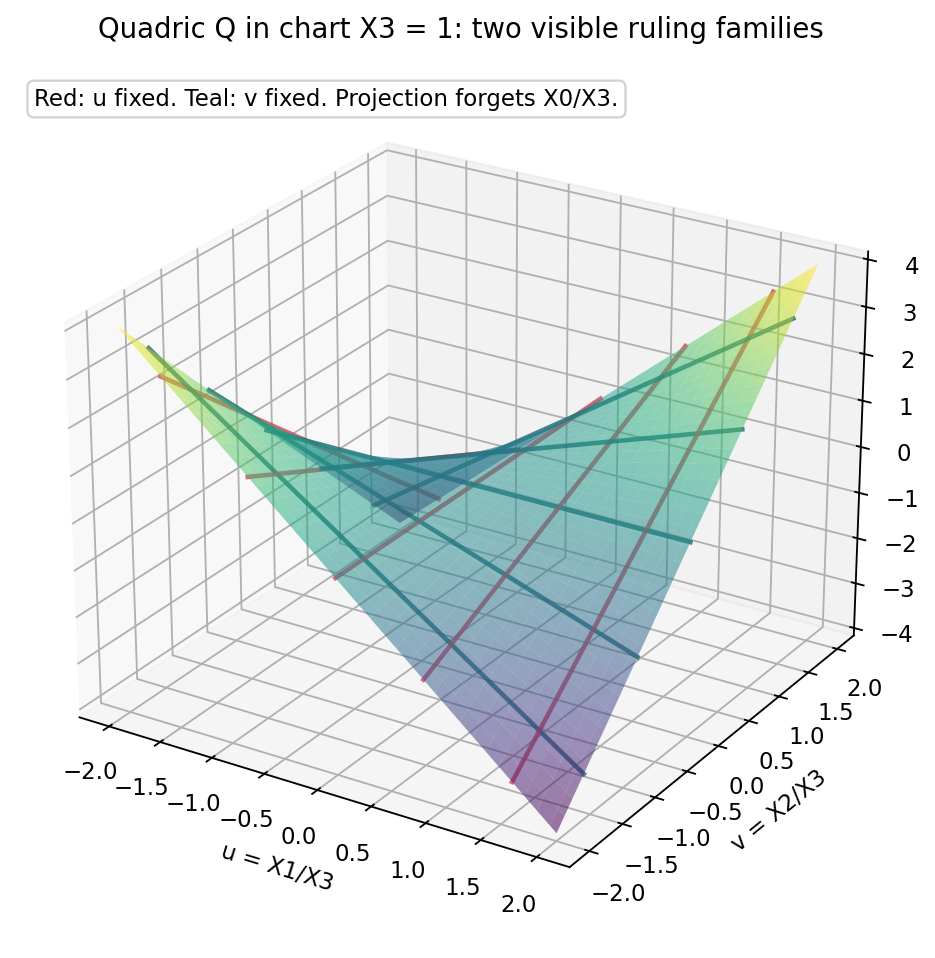

In [8]:
def draw_quadric_rulings() -> Path:
    fig = plt.figure(figsize=(9.4, 7.0))
    ax = fig.add_subplot(111, projection="3d")
    u = np.linspace(-2.0, 2.0, 70)
    v = np.linspace(-2.0, 2.0, 70)
    Ug, Vg = np.meshgrid(u, v)
    Wg = Ug * Vg
    ax.plot_surface(Ug, Vg, Wg, cmap="viridis", alpha=0.52, linewidth=0, antialiased=True)
    for c in [-1.6, -0.8, 0.0, 0.8, 1.6]:
        ax.plot(np.full_like(v, c), v, c * v, color="#d1495b", lw=2.0, alpha=0.82)
        ax.plot(u, np.full_like(u, c), u * c, color="#246a73", lw=2.0, alpha=0.82)
    ax.set_title("Quadric Q in chart X3 = 1: two visible ruling families")
    ax.set_xlabel("u = X1/X3")
    ax.set_ylabel("v = X2/X3")
    ax.set_zlabel("X0/X3 = u*v")
    ax.view_init(elev=25, azim=-58)
    ax.text2D(0.02, 0.94, "Red: u fixed. Teal: v fixed. Projection forgets X0/X3.", transform=ax.transAxes, bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#cccccc", "alpha": 0.88})
    return save_fig(fig, "quadric-projection-and-rulings.png")


A, B, C = sp.symbols("A B C")
phi_quadric = [A * B, A * C, B * C, C**2]
quadric_equation_after_phi = sp.factor(phi_quadric[0] * phi_quadric[3] - phi_quadric[1] * phi_quadric[2])
pi_after_phi = [phi_quadric[1], phi_quadric[2], phi_quadric[3]]
pi_phi_scale_residual = [sp.factor(value - C * source) for value, source in zip(pi_after_phi, [A, B, C])]

Q0, Q1, Q2, Q3 = sp.symbols("Q0 Q1 Q2 Q3")
phi_after_pi = [Q1 * Q2, Q1 * Q3, Q2 * Q3, Q3**2]
phi_pi_scale_residual = [sp.factor(value - Q3 * source) for value, source in zip(phi_after_pi, [Q0, Q1, Q2, Q3])]
assert quadric_equation_after_phi == 0
assert pi_phi_scale_residual == [0, 0, 0]
assert phi_pi_scale_residual[0] == sp.factor(Q1 * Q2 - Q0 * Q3)
assert phi_pi_scale_residual[1:] == [0, 0, 0]
metrics.update({
    "quadric_phi_lands_on_Q": str(quadric_equation_after_phi),
    "quadric_pi_phi_scale_residual": [str(item) for item in pi_phi_scale_residual],
    "quadric_phi_pi_first_residual": str(phi_pi_scale_residual[0]),
})

quadric_path = draw_quadric_rulings()
record_visual(
    "quadric projection and rulings",
    "affine chart surface z=u*v with two ruling families",
    "Matplotlib 3D for a static ruled-surface inspection; SymPy checks the projective inverse formulas",
    quadric_path,
    "Fixing u or fixing v gives straight lines on the surface; projection forgets z=u*v.",
    "The inverse formula lands on Q, and the two compositions agree up to projective scale on the open set.",
)
display_artifact(quadric_path, width=760)


In [9]:
def make_quadric_plotly_lab() -> Path:
    u = np.linspace(-2.0, 2.0, 65)
    v = np.linspace(-2.0, 2.0, 65)
    Ug, Vg = np.meshgrid(u, v)
    Wg = Ug * Vg
    fig = go.Figure()
    fig.add_trace(go.Surface(
        x=Ug, y=Vg, z=Wg,
        colorscale="Viridis", opacity=0.74, showscale=False,
        name="Q in X3=1",
        hovertemplate="u=%{x:.2f}<br>v=%{y:.2f}<br>X0/X3=%{z:.2f}<extra></extra>",
    ))
    fig.add_trace(go.Surface(
        x=Ug, y=Vg, z=np.zeros_like(Wg),
        colorscale=[[0, "rgb(235,235,235)"], [1, "rgb(235,235,235)"]],
        opacity=0.28, showscale=False, name="projection plane",
        hoverinfo="skip",
    ))
    for c in [-1.5, -0.75, 0.0, 0.75, 1.5]:
        fig.add_trace(go.Scatter3d(x=np.full_like(v, c), y=v, z=c * v, mode="lines",
                                   line={"color": "#d1495b", "width": 5}, name=f"u={c:g}"))
        fig.add_trace(go.Scatter3d(x=u, y=np.full_like(u, c), z=u * c, mode="lines",
                                   line={"color": "#246a73", "width": 5}, name=f"v={c:g}"))
    for point in [(-1.25, 1.1), (-0.4, -1.35), (0.9, 0.65), (1.45, -0.8)]:
        uu, vv = point
        ww = uu * vv
        fig.add_trace(go.Scatter3d(x=[uu, uu], y=[vv, vv], z=[0, ww], mode="lines+markers",
                                   marker={"size": 3, "color": "black"},
                                   line={"color": "black", "width": 3, "dash": "dot"},
                                   showlegend=False,
                                   hovertemplate="projection fiber over (%{x:.2f}, %{y:.2f})<extra></extra>"))
    fig.update_layout(
        title="Quadric projection lab: rotate to inspect rulings and projection fibers",
        scene={
            "xaxis_title": "A/C = X1/X3",
            "yaxis_title": "B/C = X2/X3",
            "zaxis_title": "X0/X3",
            "camera": {"eye": {"x": 1.65, "y": -1.85, "z": 1.2}},
        },
        legend={"orientation": "h", "y": -0.08},
        margin={"l": 0, "r": 0, "t": 55, "b": 0},
    )
    return save_html(fig, "quadric-birational-projection-lab.html")


quadric_html = make_quadric_plotly_lab()
record_visual(
    "birational projection lab",
    "interactive Plotly 3D surface with projection fibers and ruling lines",
    "Plotly because rotating the 3D ruled surface exposes which lines project to the affine base",
    quadric_html,
    "Rotate the surface and compare vertical projection fibers with the two straight ruling families.",
    "The symbolic cell checks the projection inverse on the dense open set C != 0.",
)
display_artifact(quadric_html, height=500)


## Birational Equivalence as a Dense-Open Statement

A birational equivalence is not the claim that two displayed formulas are everywhere inverse. It is the claim that, after discarding proper closed subsets, the remaining open pieces are isomorphic. The function field view says the same thing algebraically: the pullback gives an isomorphism of fields of rational functions.

The proof-state diagram below is intentionally a graph rather than another surface. The useful inspection target is the order of operations: identify rational formulas, locate their domains, shrink to open sets where both compositions are defined, and only then state an isomorphism.


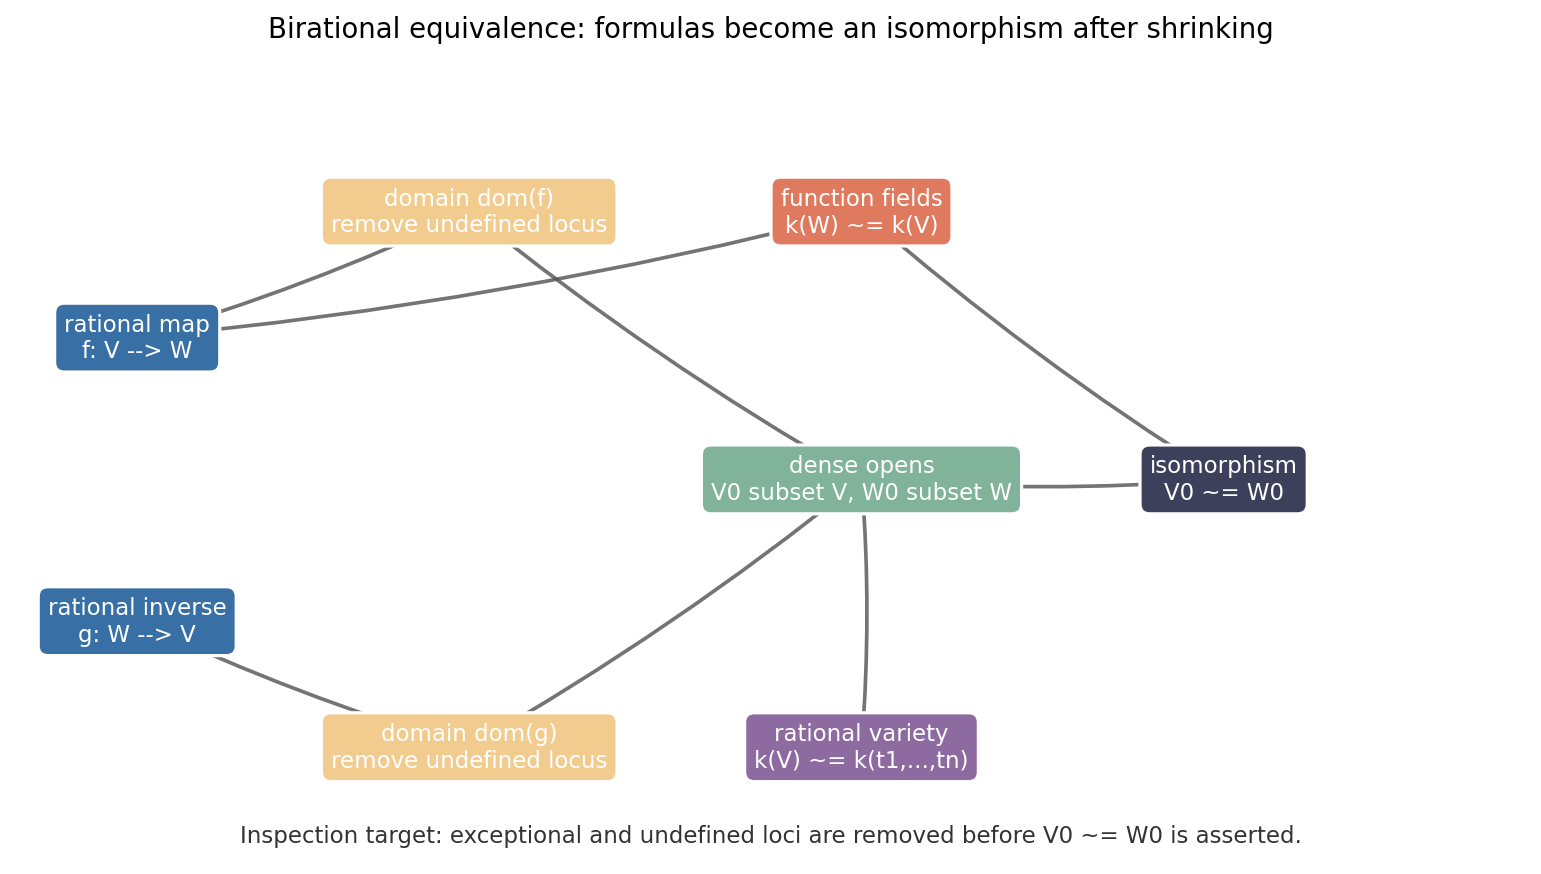

In [10]:
def draw_birational_graph() -> Path:
    fig, ax = plt.subplots(figsize=(11.8, 6.2))
    ax.axis("off")
    nodes = {
        "f": ((0.08, 0.66), "rational map\nf: V --> W"),
        "domf": ((0.30, 0.82), "domain dom(f)\nremove undefined locus"),
        "g": ((0.08, 0.30), "rational inverse\ng: W --> V"),
        "domg": ((0.30, 0.14), "domain dom(g)\nremove undefined locus"),
        "opens": ((0.56, 0.48), "dense opens\nV0 subset V, W0 subset W"),
        "iso": ((0.80, 0.48), "isomorphism\nV0 ~= W0"),
        "fields": ((0.56, 0.82), "function fields\nk(W) ~= k(V)"),
        "rational": ((0.56, 0.14), "rational variety\nk(V) ~= k(t1,...,tn)"),
    }
    edges = [
        ("f", "domf", "locate where formulas are regular"),
        ("g", "domg", "same for inverse"),
        ("domf", "opens", "shrink"),
        ("domg", "opens", "shrink"),
        ("opens", "iso", "compositions are identities"),
        ("f", "fields", "pull back functions"),
        ("fields", "iso", "same dense-open data"),
        ("rational", "opens", "parametrize by affine space"),
    ]
    color_map = {
        "f": "#386fa4", "g": "#386fa4", "domf": "#f2cc8f", "domg": "#f2cc8f",
        "opens": "#81b29a", "iso": "#3d405b", "fields": "#e07a5f", "rational": "#8d6a9f",
    }
    for start, end, label in edges:
        (x0, y0), _ = nodes[start]
        (x1, y1), _ = nodes[end]
        arrow = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=13,
                                lw=1.6, color="#555555", alpha=0.82, connectionstyle="arc3,rad=0.04")
        ax.add_patch(arrow)
    for key, ((xpos, ypos), label) in nodes.items():
        ax.text(xpos, ypos, label, ha="center", va="center", color="white", fontsize=10,
                bbox={"boxstyle": "round,pad=0.42", "fc": color_map[key], "ec": "white", "lw": 1.4})
    ax.set_title("Birational equivalence: formulas become an isomorphism after shrinking", pad=14)
    ax.text(0.5, 0.02, "Inspection target: exceptional and undefined loci are removed before V0 ~= W0 is asserted.",
            ha="center", color="#333333")
    metrics["birational_graph_nodes"] = len(nodes)
    metrics["birational_graph_edges"] = len(edges)
    return save_fig(fig, "birational-equivalence-open-sets.png")


birational_path = draw_birational_graph()
record_visual(
    "birational equivalence",
    "proof-state dependency graph for rational maps, domains, open sets, and fields",
    "NetworkX/Matplotlib-style graph because the concept is logical dependency rather than a metric drawing",
    birational_path,
    "Follow the arrows to see why dense open sets appear in the definition and proposition.",
    "Graph metrics record node and edge counts; symbolic quadric checks give a concrete birational example.",
)
display_artifact(birational_path, width=840)


## Products, Segre Coordinates, and Veronese Rank-One Conditions

The Segre embedding turns a pair of projective points into all pairwise products. For `P^1 x P^1`, the four coordinates form a `2 x 2` matrix

`[[X0*Y0, X0*Y1], [X1*Y0, X1*Y1]]`,

and the image is exactly the rank-one locus, cut out by the determinant. This is the same quadric model used above.

The Veronese embedding of `P^2` by quadrics is similar but symmetric. Its six coordinates fill the symmetric matrix

`[[X^2, XY, XZ], [XY, Y^2, YZ], [XZ, YZ, Z^2]] = [X,Y,Z]^T [X,Y,Z]`.

All `2 x 2` minors vanish because the matrix has rank one. This is the computational core behind many projective embeddings in the chapter exercises.


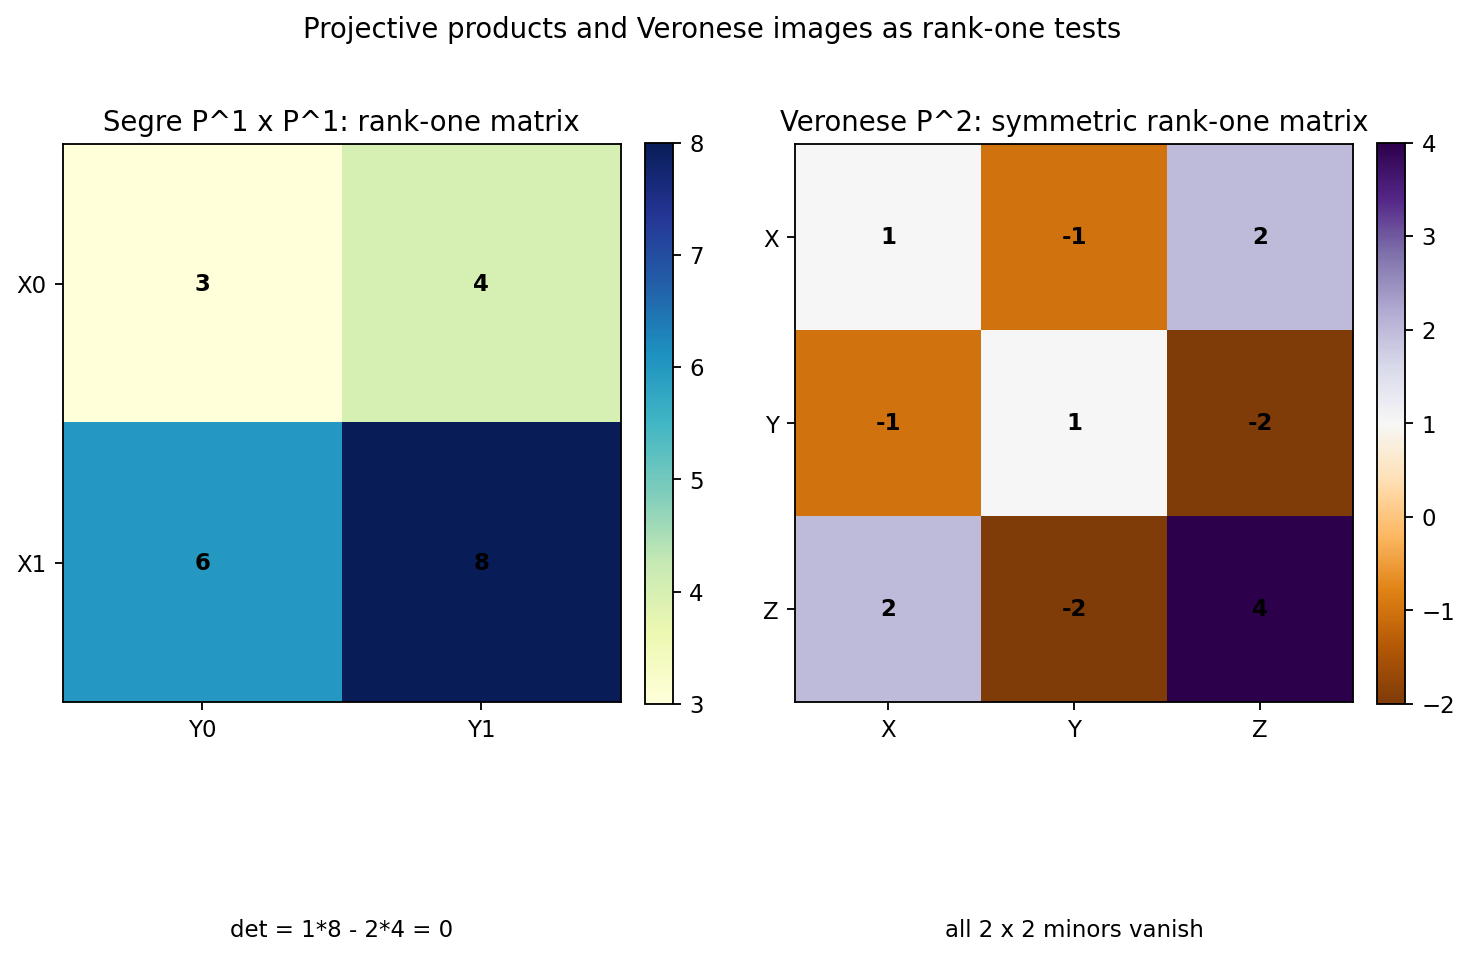

In [11]:
def draw_segre_veronese_rank_conditions() -> Path:
    segre_sample = np.outer(np.array([1, 2]), np.array([3, 4]))
    veronese_vector = np.array([1, -1, 2])
    veronese_sample = np.outer(veronese_vector, veronese_vector)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.7))
    im0 = axes[0].imshow(segre_sample, cmap="YlGnBu")
    axes[0].set_title("Segre P^1 x P^1: rank-one matrix")
    axes[0].set_xticks([0, 1], labels=["Y0", "Y1"])
    axes[0].set_yticks([0, 1], labels=["X0", "X1"])
    for (i, j), value in np.ndenumerate(segre_sample):
        axes[0].text(j, i, str(int(value)), ha="center", va="center", weight="bold")
    axes[0].text(0.5, -0.42, "det = 1*8 - 2*4 = 0", ha="center", transform=axes[0].transAxes)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(veronese_sample, cmap="PuOr")
    axes[1].set_title("Veronese P^2: symmetric rank-one matrix")
    axes[1].set_xticks([0, 1, 2], labels=["X", "Y", "Z"])
    axes[1].set_yticks([0, 1, 2], labels=["X", "Y", "Z"])
    for (i, j), value in np.ndenumerate(veronese_sample):
        axes[1].text(j, i, str(int(value)), ha="center", va="center", weight="bold")
    axes[1].text(0.5, -0.42, "all 2 x 2 minors vanish", ha="center", transform=axes[1].transAxes)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.suptitle("Projective products and Veronese images as rank-one tests", y=1.02)
    return save_fig(fig, "segre-veronese-rank-one.png")


s0, s1, t0, t1 = sp.symbols("s0 s1 t0 t1")
segre_matrix = sp.Matrix([[s0 * t0, s0 * t1], [s1 * t0, s1 * t1]])
segre_det = sp.factor(segre_matrix.det())
assert segre_det == 0

VX, VY, VZ = sp.symbols("VX VY VZ")
A0, A1, A2, A3, A4, A5 = sp.symbols("A0 A1 A2 A3 A4 A5")
veronese_matrix = sp.Matrix([[A0, A1, A2], [A1, A3, A4], [A2, A4, A5]])
veronese_subs = {A0: VX**2, A1: VX * VY, A2: VX * VZ, A3: VY**2, A4: VY * VZ, A5: VZ**2}
veronese_minors = []
for row_pair in combinations(range(3), 2):
    for col_pair in combinations(range(3), 2):
        veronese_minors.append(sp.factor(veronese_matrix.extract(row_pair, col_pair).det().subs(veronese_subs)))
assert all(item == 0 for item in veronese_minors)
metrics.update({
    "segre_determinant": str(segre_det),
    "veronese_2x2_minor_values": sorted({str(item) for item in veronese_minors}),
})

rank_path = draw_segre_veronese_rank_conditions()
record_visual(
    "Segre and Veronese embeddings",
    "numeric rank-one matrix heatmaps plus exact symbolic minor checks",
    "Matplotlib for compact matrix inspection; SymPy for exact determinantal identities",
    rank_path,
    "Rows and columns are proportional because the displayed matrices are outer products.",
    "The Segre determinant and all Veronese 2 x 2 minors vanish symbolically.",
)
display_artifact(rank_path, width=820)


## Applied Lab: Locate the Exceptional Loci

Use the quadric projection as the working lab. The projection `pi` is undefined at `P0 = [1:0:0:0]`. Inside the quadric, the two ruling lines through `P0` are

`L1: X2 = X3 = 0`, and `L2: X1 = X3 = 0`.

Away from these two lines, and in the target chart `C = X3 != 0`, projection and the quadratic inverse are mutually inverse up to projective scale. The table saved below records which chapter concept each artifact teaches and which invariant checks it.


In [12]:
concept_table = pd.DataFrame(storyboard_rows)
concept_table_path = save_table(concept_table, "concept-routing.csv")

exceptional_samples = pd.DataFrame([
    {"locus": "P0", "point": "[1:0:0:0]", "on_Q": True, "pi_defined": False, "role": "center of projection"},
    {"locus": "L1 minus P0", "point": "[2:1:0:0]", "on_Q": True, "pi_defined": True, "role": "contracted to [1:0:0]"},
    {"locus": "L2 minus P0", "point": "[2:0:1:0]", "on_Q": True, "pi_defined": True, "role": "contracted to [0:1:0]"},
    {"locus": "open chart", "point": "[6:2:3:1]", "on_Q": True, "pi_defined": True, "role": "maps to [2:3:1] and recovers up to scale"},
])
exceptional_table_path = save_table(exceptional_samples, "quadric-exceptional-loci.csv")

metrics["concept_table_rows"] = int(len(concept_table))
metrics["quadric_exceptional_loci_rows"] = int(len(exceptional_samples))

display(concept_table[["concept", "artifact", "validation_or_invariant"]])
display_artifact(exceptional_table_path)


,concept,artifact,validation_or_invariant
0,homogeneous projective variety,artifacts/chapter-05/figures/homogeneous-cone-...,The sampled residual X0*X2 - X1^2 is zero up t...
1,P^1 affine chart gluing,artifacts/chapter-05/figures/projective-line-g...,"For sampled overlap points, x*y - 1 has zero m..."
2,projective cubic affine chart cover,artifacts/chapter-05/figures/projective-cubic-...,Substituted overlap samples satisfy the Y=1 ch...
3,rational normal curve / twisted cubic,artifacts/chapter-05/figures/rational-normal-c...,All three Hankel 2 x 2 minors vanish after sub...
4,quadric projection and rulings,artifacts/chapter-05/figures/quadric-projectio...,"The inverse formula lands on Q, and the two co..."
5,birational projection lab,artifacts/chapter-05/html/quadric-birational-p...,The symbolic cell checks the projection invers...
6,birational equivalence,artifacts/chapter-05/figures/birational-equiva...,Graph metrics record node and edge counts; sym...
7,Segre and Veronese embeddings,artifacts/chapter-05/figures/segre-veronese-ra...,The Segre determinant and all Veronese 2 x 2 m...


## Final Sanity Checks

The final cell checks three layers at once.

1. **Core identities.** Homogeneous scaling, chart gluing, rank-one minors, and quadric inverse formulas must simplify exactly.
2. **Artifact integrity.** Every generated figure, HTML file, JSON check file, and table must exist under `artifacts/chapter-05` and be nonempty; PNGs must have nontrivial pixel variation.
3. **Path correctness.** Generated paths must stay inside the chapter-05 artifact subtree and remain book-local.


In [13]:
symbolic_payload = {
    "source_span": "printed pages 87-100; physical PDF pages 85-98",
    "core_symbolic_metrics": metrics,
    "rational_normal_minors": [str(item) for item in rnc_minors],
    "quadric_exceptional_loci": [
        {"name": "center P0", "equations": ["X1=0", "X2=0", "X3=0"]},
        {"name": "ruling line L1", "equations": ["X2=0", "X3=0"]},
        {"name": "ruling line L2", "equations": ["X1=0", "X3=0"]},
    ],
    "generated_artifacts": {kind: [book_rel(path) for path in group] for kind, group in paths.items()},
}
symbolic_check_path = save_check(symbolic_payload, "symbolic-invariants.json")

artifact_summary = {
    "figures": [image_stats(path) for path in paths["figures"]],
    "html": [{"path": book_rel(path), "file_size": int(Path(path).stat().st_size)} for path in paths["html"]],
    "tables": [{"path": book_rel(path), "file_size": int(Path(path).stat().st_size)} for path in paths["tables"]],
    "checks_before_final": [{"path": book_rel(path), "file_size": int(Path(path).stat().st_size)} for path in paths["checks"]],
}
artifact_summary_path = save_check(artifact_summary, "artifact-summary.json")

assert metrics["homogeneous_scaling_identity"] == "0"
assert metrics["cubic_chart_glue_identity"] == "0"
assert metrics["rational_normal_curve_minor_values"] == ["0", "0", "0"]
assert metrics["quadric_phi_lands_on_Q"] == "0"
assert metrics["quadric_pi_phi_scale_residual"] == ["0", "0", "0"]
assert metrics["segre_determinant"] == "0"
assert metrics["veronese_2x2_minor_values"] == ["0"]

all_generated = [path for group in paths.values() for path in group]
assert_artifacts(all_generated, min_size=256)
for path in all_generated:
    Path(path).resolve().relative_to(ARTIFACT_ROOT.resolve())
    Path(path).resolve().relative_to(BOOK_ROOT.resolve())

summary = validate_chapter_outputs(paths, min_pngs=6)
final_sanity = write_final_sanity(ARTIFACT_ROOT, paths, metrics)
add_artifact("checks", final_sanity)
assert final_sanity.name == "final-sanity.json"
assert final_sanity.exists() and final_sanity.stat().st_size > 256

Markdown(
    f"Sanity checks passed for {summary['figures']} figures, {summary['html']} HTML artifact, "
    f"and {summary['checks']} pre-final check artifacts. Final report: `{book_rel(final_sanity)}`."
)


Sanity checks passed for 7 figures, 1 HTML artifact, and 2 pre-final check artifacts. Final report: `artifacts/chapter-05/checks/final-sanity.json`.

## Takeaways

- Projective equations must be homogeneous because only homogeneous zero conditions survive the choice of representative.
- Affine charts are not optional bookkeeping. They are how projective objects become computable, and chart overlap formulas are part of the data.
- Rational functions on a projective variety are quotients of same-degree homogeneous forms; their domains are dense open sets where denominators do not vanish.
- A rational map becomes a morphism only where some representative coordinate tuple is regular and not all zero.
- Birational equivalence means equality after shrinking to dense open sets. Exceptional and undefined loci are not errors; they are the geometry that must be named.
- Rank-one matrices organize the chapter's central projective examples: rational normal curves, Segre products, quadrics, and Veronese embeddings.
